# 📊 Verteilungsanalyse: Elite Herren (Männer Hauptklasse)

**Ziel:** Analyse der Verteilung der IAAF Scores für die Altersklasse "Männer". 
Dies dient als Vorbereitung für statistische Tests (z.B. t-Tests, ANOVA, Regression), um zu prüfen, ob die Annahme der Normalverteilung verletzt ist.

In [ ]:
import pandas as pd
import numpy as np
import lib.plotting_style as plt
from scipy import stats
import seaborn as sns

from lib import util
from lib.plotting_style import rgb
from lib import plotting_style as plt_style

# Load Data
df = util.load_data()

# Filter for Elite Men (Männer Hauptklasse)
# Assuming 'Männer' is the label in 'altersklasse' and 'M' in 'geschlecht'
df_men = df[(df['altersklasse'] == 'Maenner')].copy()

print(f"Datensätze für Elite Herren: {len(df_men)}")
df_men.head()

Datensätze für Elite Herren: 24169


,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,group
4454,2005,M,Maenner,100 m,10.16,0.3,Tobias Unger,1979,LAZ Salamander Kornwesth./Lud.,02.07.,Wattenscheid,1152.0,Sprint
4455,2005,M,Maenner,100 m,10.28,1.3,Alexander Kosenkow,1977,TV Wattenscheid 01,02.07.,Wattenscheid,1112.0,Sprint
4456,2005,M,Maenner,100 m,10.29,0.3,Marc Blume,1973,TV Wattenscheid 01,02.07.,Wattenscheid,1108.0,Sprint
4457,2005,M,Maenner,100 m,10.31,0.3,Marius Broening,1983,LAV asics Tuebingen,02.07.,Wattenscheid,1102.0,Sprint
4458,2005,M,Maenner,100 m,10.37,0.8,Daniel Schnelting,1986,LAZ Rhede,29.07.,Braunschweig,1082.0,Sprint


## 1. Histogramm & Dichtefunktion (KDE)
Hier sehen wir die generelle Form der Verteilung. Ist sie symmetrisch? Gibt es "Fat Tails"?

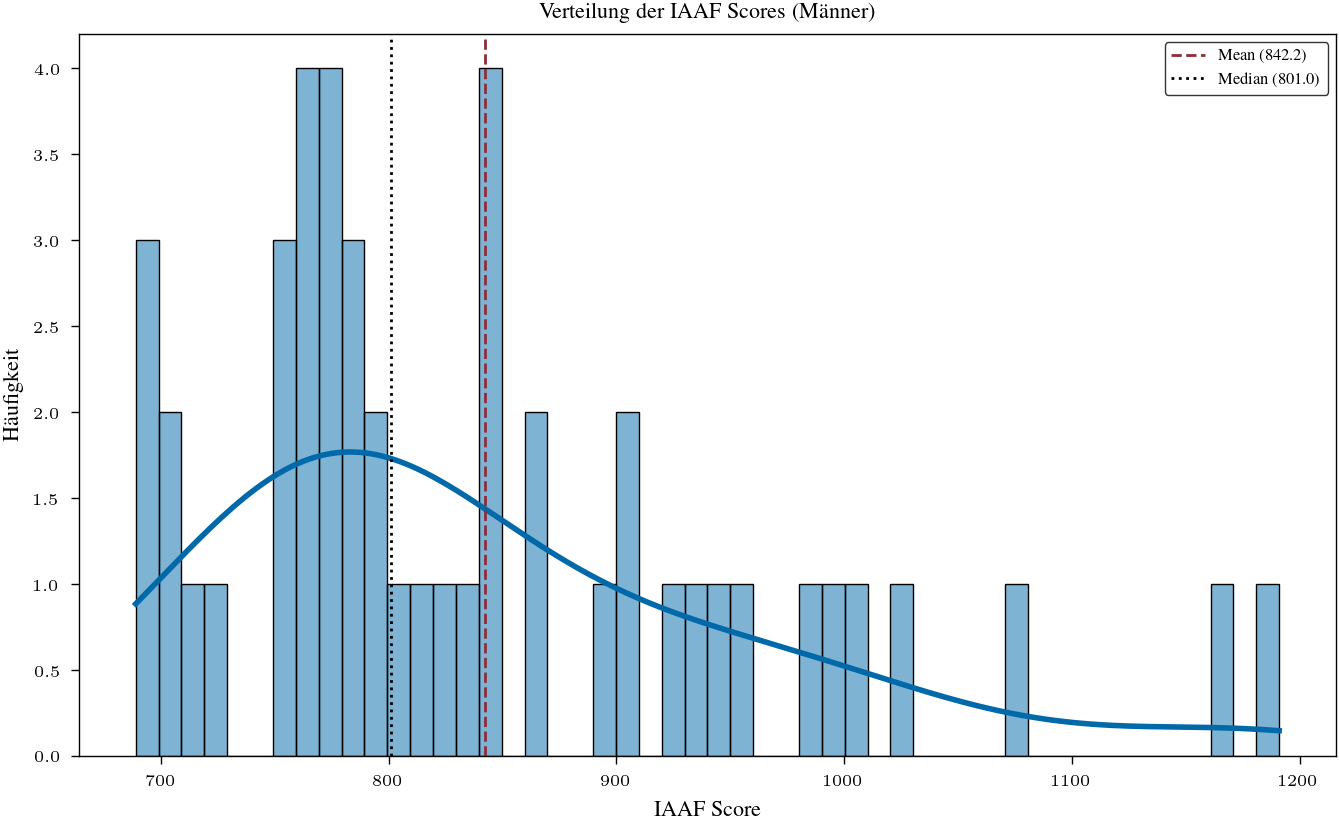

In [2]:
with plt.rc_context():
    fig, ax = plt.subplots()

    df_men_2024_100m = df_men[(df_men['jahr'] == 2024) & (df_men['disziplin'] == 'Hammerwurf')]
    
    # Histogram with Kernel Density Estimate
    sns.histplot(df_men_2024_100m['iaaf_score'], kde=True, color=rgb.tue_blue, bins=50, ax=ax, line_kws={'linewidth': 2})
    
    # Add Mean and Median lines
    mean_val = df_men_2024_100m['iaaf_score'].mean()
    median_val = df_men_2024_100m['iaaf_score'].median()
    
    ax.axvline(mean_val, color=rgb.tue_red, linestyle='--', label=f'Mean ({mean_val:.1f})')
    ax.axvline(median_val, color='black', linestyle=':', label=f'Median ({median_val:.1f})')
    
    ax.set_title('Verteilung der IAAF Scores (Männer)')
    ax.set_xlabel('IAAF Score')
    ax.set_ylabel('Häufigkeit')
    ax.legend()
    
    plt.show()

## 2. Q-Q Plot (Quantile-Quantile)
Der Q-Q Plot vergleicht die Datenquantile mit den theoretischen Quantilen einer Normalverteilung. 
*   Liegen die Punkte auf der roten Linie, sind die Daten normalverteilt.
*   Abweichungen an den Enden deuten auf "Heavy Tails" (Ausreißer) hin.

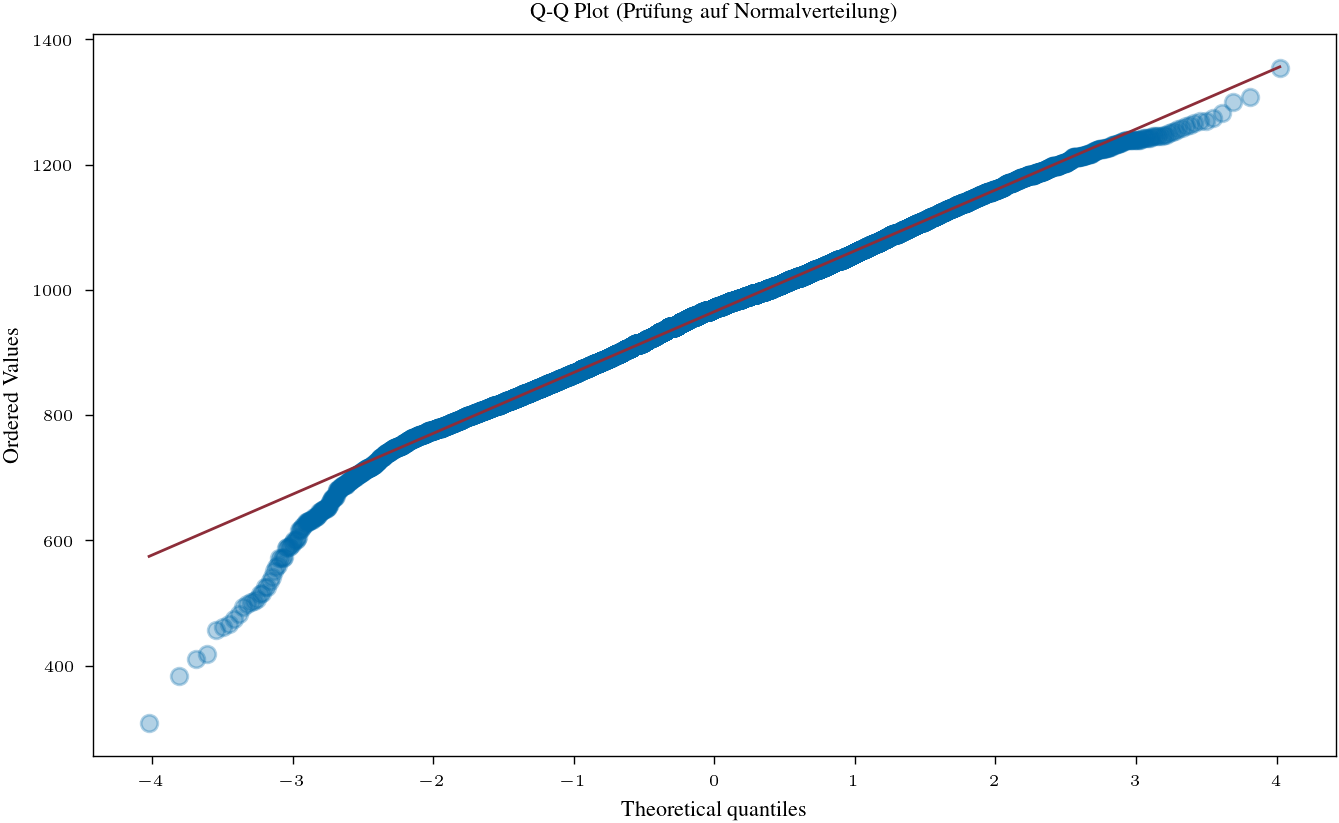

In [4]:

fig, ax = plt.subplots()

# Generate Q-Q plot
stats.probplot(df_men['iaaf_score'], dist="norm", plot=ax)

ax.get_lines()[0].set_markerfacecolor(rgb.tue_blue)
ax.get_lines()[0].set_markeredgecolor(rgb.tue_blue)
ax.get_lines()[0].set_alpha(0.3)
ax.get_lines()[1].set_color(rgb.tue_red) # The regression line

ax.set_title('Q-Q Plot (Prüfung auf Normalverteilung)')
plt.show()

## 3. Statistische Kennzahlen
Numerische Überprüfung der Verteilungseigenschaften.

In [5]:
desc_stats = df_men['iaaf_score'].describe()
skewness = df_men['iaaf_score'].skew()
kurtosis = df_men['iaaf_score'].kurtosis()

print("=== Deskriptive Statistik (IAAF Score - Männer) ===")
print(desc_stats)
print("=== Form der Verteilung ===")
print(f"Schiefe (Skewness): {skewness:.4f} (0 = symmetrisch, >0 = rechtsschief, <0 = linksschief)")
print(f"Wölbung (Kurtosis): {kurtosis:.4f} (0 = Normalverteilung [Fisher], >0 = steilgipflig, <0 = flachgipflig)")

if abs(skewness) > 0.5:
    print("HINWEIS: Die Daten weisen eine merkliche Schiefe auf. Parametrische Tests (z.B. t-Test) sind ggf. mit Vorsicht zu genießen oder erfordern Transformationen.")
else:
    print("HINWEIS: Die Daten sind annähernd symmetrisch.")

=== Deskriptive Statistik (IAAF Score - Männer) ===
count    24169.000000
mean       965.346436
std         97.336180
min        308.000000
25%        899.000000
50%        971.000000
75%       1027.000000
max       1355.000000
Name: iaaf_score, dtype: float64
=== Form der Verteilung ===
Schiefe (Skewness): -0.1628 (0 = symmetrisch, >0 = rechtsschief, <0 = linksschief)
Wölbung (Kurtosis): 0.5739 (0 = Normalverteilung [Fisher], >0 = steilgipflig, <0 = flachgipflig)
HINWEIS: Die Daten sind annähernd symmetrisch.


---
# 4. Deep Dive: 100m Sprint
Wir betrachten nun spezifisch die **100m** Disziplin. Da dies eine der populärsten Disziplinen mit hoher Leistungsdichte ist, ist die Verteilung hier besonders interessant.

Datensätze für 100m Männer: 1182


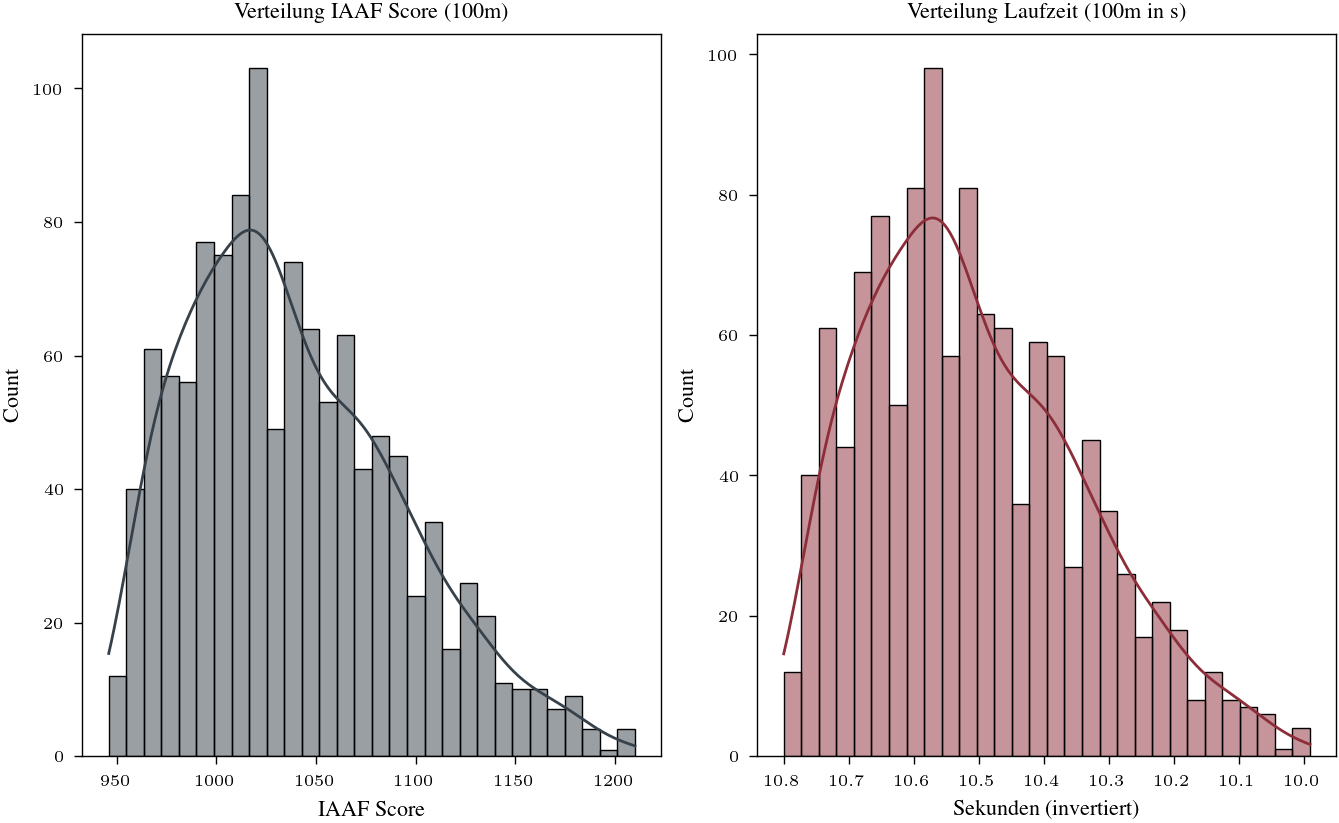

In [6]:
# Filter for 100m Men
df_100m = df_men[df_men['disziplin'] == '100 m'].copy()

print(f"Datensätze für 100m Männer: {len(df_100m)}")


fig, (ax1, ax2) = plt.subplots(1, 2)

# 1. Histogram (IAAF Score)
sns.histplot(df_100m['iaaf_score'], kde=True, color=rgb.tue_dark, bins=30, ax=ax1)
ax1.set_title('Verteilung IAAF Score (100m)')
ax1.set_xlabel('IAAF Score')

# 2. Histogram (Raw Performance in seconds)
# Note: Lower seconds = better, so the distribution is mirrored compared to points
sns.histplot(df_100m['leistung'], kde=True, color=rgb.tue_red, bins=30, ax=ax2)
ax2.invert_xaxis() # Faster times on the right to match logic of "better performance"
ax2.set_title('Verteilung Laufzeit (100m in s)')
ax2.set_xlabel('Sekunden (invertiert)')

plt.show()

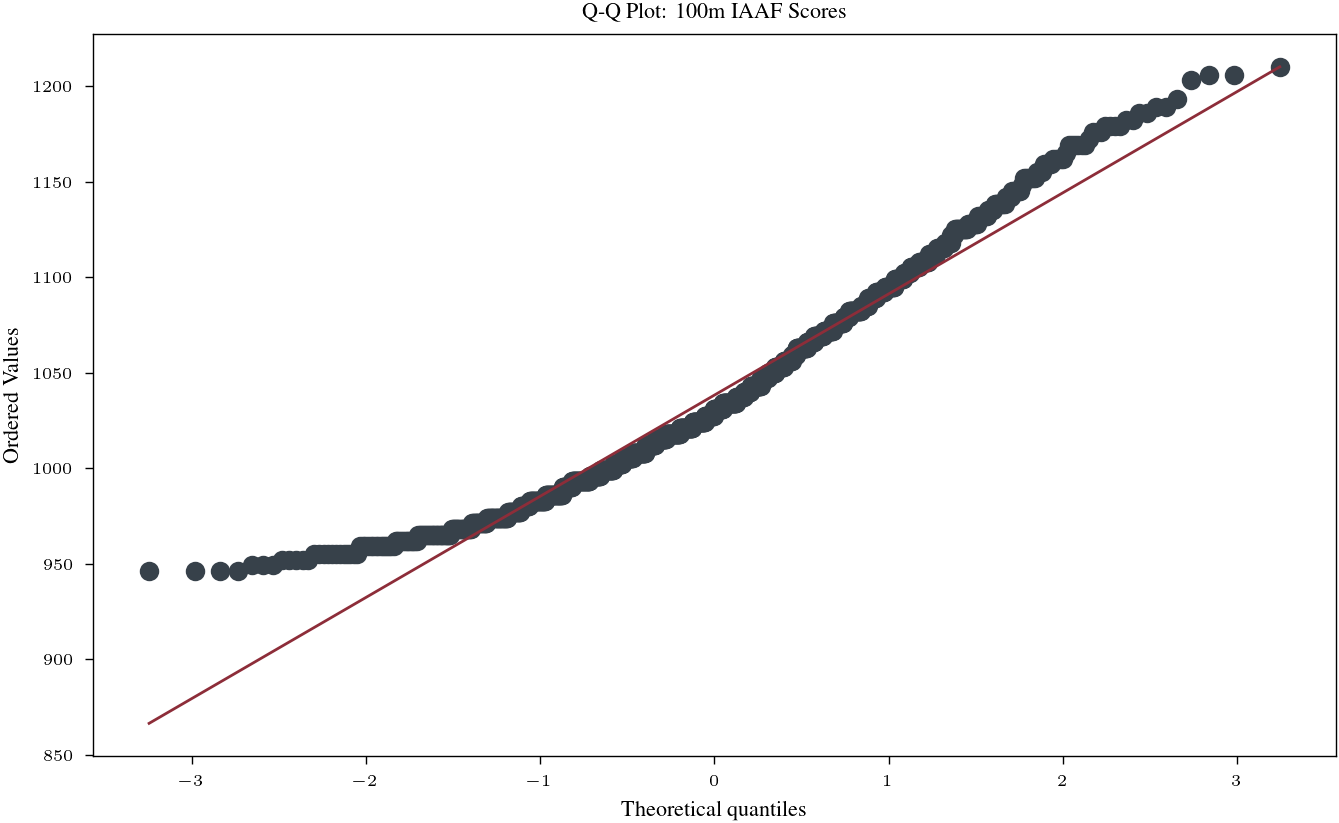

In [7]:
# Q-Q Plot für 100m

fig, ax = plt.subplots()
stats.probplot(df_100m['iaaf_score'], dist="norm", plot=ax)
ax.get_lines()[0].set_markerfacecolor(rgb.tue_dark)
ax.get_lines()[0].set_markeredgecolor(rgb.tue_dark)
ax.get_lines()[1].set_color(rgb.tue_red)
ax.set_title('Q-Q Plot: 100m IAAF Scores')
plt.show()